# Cancer protein-protein interaction network
In this notebook we are going to work with a PPI network of proteins that are upregulated in ovarian cancer cells compared to healthy cells. 
Network analysis can help us understand what are the interactions between these proteins, which proteins are likely more important for the cancer cell and whether some proteins group together.

This network was obtained by supplying a list of upregulated genes ([example dataset from Cytoscape](https://cytoscape.org/cytoscape-tutorials/protocols/differentially-expressed-genes/#/ex1-up-string)) to [String database](https://string-db.org/) where they are automatically mapped to protein interaction network.

After doing network analysis, we could continue with further methods such as pathway enrichment or gene set enrichment (for example in [Cytoscape](https://github.com/cytoscape/cytoscape-tutorials/wiki)).

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # plotting package

# plotting settings
%matplotlib inline 
plt.rcParams['figure.figsize'] = [12, 6] # set the size of a figure

In [2]:
# read csv file with the edges
path = "string_interactions.tsv"
nodes = pd.read_csv(path, sep = '\t')

In [3]:
# the network is represented as a list of edges between nodes
nodes.head()

,#node1,node2,node1_string_id,node2_string_id,neighborhood_on_chromosome,gene_fusion,phylogenetic_cooccurrence,homology,coexpression,experimentally_determined_interaction,database_annotated,automated_textmining,combined_score
0,ABCA6,ABCA8,9606.ENSP00000284425,9606.ENSP00000467271,0.0,0.0,0.0,0.96,0.291,0.368,0.0,0.923,0.550
1,ACTG2,EEF1A2,9606.ENSP00000386857,9606.ENSP00000217182,0.0,0.0,0.0,0.00,0.185,0.257,0.0,0.280,0.526
2,ACTG2,ATP1B2,9606.ENSP00000386857,9606.ENSP00000250111,0.0,0.0,0.0,0.00,0.000,0.069,0.0,0.627,0.638
3,ACTG2,MYH11,9606.ENSP00000386857,9606.ENSP00000379616,0.0,0.0,0.0,0.00,0.566,0.369,0.6,0.641,0.955
4,ADAM12,MMP2,9606.ENSP00000357668,9606.ENSP00000219070,0.0,0.0,0.0,0.00,0.173,0.000,0.0,0.425,0.504


In [4]:
# convert the data frame to an array and select the columns with nodes
node_array = np.array(nodes)[:,0:2]

In [5]:
# create a graph from the node array
G = nx.Graph()
G.add_edges_from(node_array)

In [6]:
# print number of nodes in each connected component - the network is disconnected
for i in nx.connected_components(G):
    print(len(i))

2
109
2
2
2
2
3
2
2
2


In [7]:
# we take only the giant component for our analysis
giant_component = max(nx.connected_components(G), key=len)

In [8]:
# create a subnetwork
# use this subnetwork for all the subsequent exercises
G1 = G.subgraph(giant_component)

## Exercise 1
Calculate clustering coefficient of all nodes in the `G1` network using the function `nx.clustering`. High clustering coefficient may indicate that a protein has an important fucntion in the network. Which nodes have a clustering coefficient higher than 0.8?

In [9]:
results = []
for node, clustering_coef in nx.clustering(G1).items():
    if clustering_coef > 0.8:
        print(node, round(clustering_coef, 2))
        results.append(node)

ADAM12 0.9
ADAMTS16 1.0
CYP26B1 1.0
FNDC1 1.0
ECM2 1.0
SFRP4 1.0
B3GAT1 1.0
CDH11 0.84
COL16A1 0.82
COL8A1 1.0
COL26A1 1.0
FAP 1.0
PRRX1 1.0
COL6A6 1.0


## Exercise 2
Calculate average clustering coefficient and transitivity of the network.

In [10]:
print(f"The avg. clustering coefficient is: {nx.average_clustering(G1):.3}")
print(f"The transitivity is: {nx.transitivity(G1):.3}")

The avg. clustering coefficient is: 0.359
The transitivity is: 0.464


## Exercise 3
The numbers from the previous exercise do not tell us much, unless we compare them to a random network.
Use the function `nx.random_reference` to randomize the network (swap edges).
Then calculate average clustering and transitivity. 
How do the properties compare to our original network? What does it tell us about the network?

In [11]:
randomized = nx.random_reference(G1)
print(f"The avg. clustering coefficient of randomized network is: {nx.average_clustering(randomized):.3}")
print(f"The transitivity of randomized network is: {nx.transitivity(randomized):.3}")

The avg. clustering coefficient of randomized network is: 0.225
The transitivity of randomized network is: 0.226


## Exercise 4
If you rerun the code from exerecise 3 several times, you will see that you always get slightly different number. To get a representative sample, use a for loop to randomize the network 50 times (it might take a while to run) and for each run calculate the avg. clustering coefficient and transitivity. Calculate the mean and standard deviation of the avg. clustering coefficent and transitivity.

In [12]:
clustering = []
transitivity = []

for i in range(50):
    randomized = nx.random_reference(G1)
    clustering.append(nx.average_clustering(randomized))
    transitivity.append(nx.transitivity(randomized))

avg_cl = np.mean(clustering)
sd_cl =  np.std(clustering)
avg_tr = np.mean(transitivity)
sd_tr = np.std(transitivity)

print(f"The avg. clustering coefficient of randomized network is: {avg_cl:.3} +- {sd_cl:.3}")
print(f"The transitivity of randomized network is: {avg_tr:.3} +- {sd_tr:.3}")

The avg. clustering coefficient of randomized network is: 0.227 +- 0.0189
The transitivity of randomized network is: 0.226 +- 0.0126


## Exercise 5
**Detecting communities** -
Communities are clusters of nodes that are more densely connected to themselves than to the rest of the network.
The following code calculates the communities using greedy modularity maximization - bottom up (agglomerative) clustering.
The result is converted to a dictionary to make it easier to work with.

In [13]:
# calcualte communities 
from networkx.algorithms.community import greedy_modularity_communities
communities = greedy_modularity_communities(G1)

# the result comes as a "FrozenSet"
# to make the next exercises easier, we convert it to a dictionary
# keys - the index of the community, values - list of nodes in each community
community_dict = {}
for index, community in enumerate(communities):
    community_dict[index] = list(community)

Use the dictionary of communities (`community_dict`) to calculate how many communities there are, and how many nodes there are in the largest and smallest community.

In [14]:
len(community_dict)

7

In [15]:
# solution with a for loop
sizes = []
for community_number, members in community_dict.items():
    sizes.append(len(members))

print(f"The largest community has {max(sizes)} nodes.")
print(f"The smallest community has {min(sizes)} nodes.")

The largest community has 28 nodes.
The smallest community has 2 nodes.


In [16]:
sizes

[28, 23, 23, 15, 13, 5, 2]

In [17]:
# solution without a for loop
largest = max(community_dict.values(), key=len)
smallest = min(community_dict.values(), key=len)

print(f"The largest community has {len(largest)} nodes.")
print(f"The smallest community has {len(smallest)} nodes.")

The largest community has 28 nodes.
The smallest community has 2 nodes.


## Exercise 6a
Draw the network with `nx.draw`/ `nx.draw_networkx`. Color the nodes based on the community they belong to. You can input a list of colors or a list of numbers into `nx.draw`/ `nx.draw_networkx`  - they will be automatically mapped to a nice color palette.

In [18]:
# make an empty list to store values
community_assignment = []

# iterate over nodes
for node in G1.nodes:
    # iterate over commynities
    for community_number, community in community_dict.items():
        
        # if the node is present in the commynity, add the index to the community_assignment list
        if node in community:
            community_assignment.append(community_number)

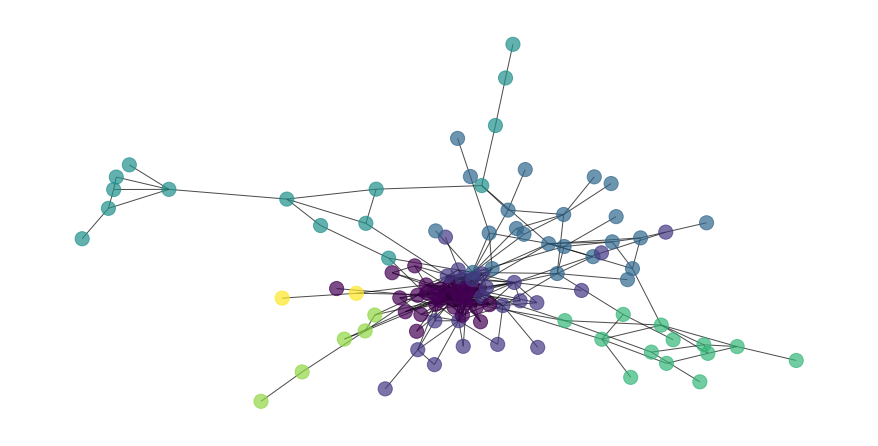

In [19]:
positions = nx.spring_layout(G1, seed = 18)
nx.draw(G1, node_color = community_assignment, node_size = 200, alpha = 0.7, pos = positions)
plt.savefig("cancer_communities")

## Exercise 6b
Now do the same for a randomized network. Calculate the communities for the randomized network and then plot them. (You can rerun it a few times, but basically you should always see that the communities disappear).

In [20]:
randomized = nx.random_reference(G1)
communities_random = nx.algorithms.community.greedy_modularity_communities(randomized)
community_dict_random = {}
for index, community in enumerate(communities_random):
    community_dict_random[index] = list(community)

In [21]:
community_assignment_random = []
for node in randomized.nodes:
    for community_number, community in community_dict.items():
        if node in community:
            community_assignment_random.append(community_number)

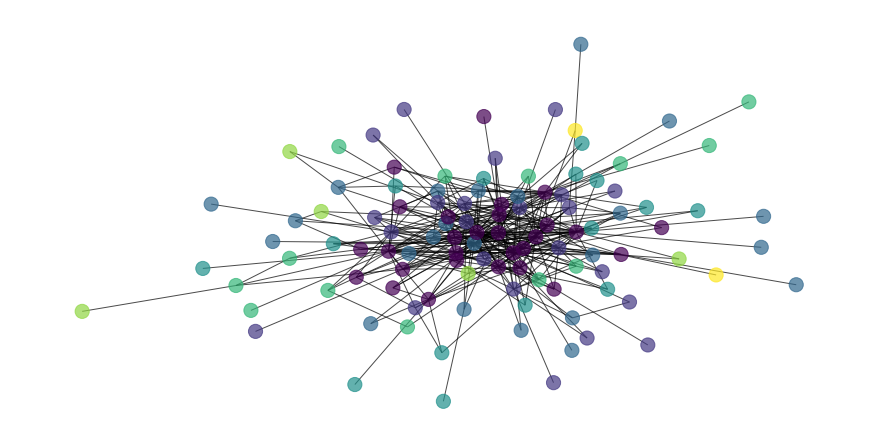

In [22]:
nx.draw(randomized, node_color = community_assignment_random, node_size = 200, alpha = 0.7)
plt.savefig("random_communities")

## Exercise 7 (optional)

Color the nodes of the original network based on their expression. The expression data is in the excel file 'TCGA-Ovarian-MesenvsImmuno_UP.xlsx', the column logFC represents the log fold change. Note that the network has protein names and the original data is gene names. You can use string-db to download the mapping.

In [23]:
expression = pd.read_csv("TCGA-Ovarian-MesenvsImmuno_UP.csv", index_col = 0)
expression.head()

,logFC,FDR adjusted Pvalue
Gene,,
9543,6.086663,7.110000e-33
165,2.119808,3.260000e-30
2200,2.110410,1.210000e-29
1307,1.870070,2.530000e-29
633,1.863731,2.530000e-29


In [24]:
mapping = pd.read_csv("string_mapping.tsv", sep = "\t", index_col = 3)
mapping.head()

,#queryIndex,queryItem,stringId,annotation
preferredName,,,,
IGDCC3,1,9543,9606.ENSP00000332773,Immunoglobulin superfamily DCC subclass member 3.
AEBP1,2,165,9606.ENSP00000223357,Adipocyte enhancer-binding protein 1; [Isoform...
FBN1,3,2200,9606.ENSP00000325527,Fibrillin-1; [Fibrillin-1]: Structural compone...
COL16A1,4,1307,9606.ENSP00000362776,Collagen alpha-1(XVI) chain; Involved in media...
BGN,5,633,9606.ENSP00000327336,Biglycan; May be involved in collagen fiber as...


In [25]:
expression_vals = []
for node in G1.nodes:
    try:
        logFC = expression.loc[mapping.loc[node].queryItem].logFC
        expression_vals.append(logFC)
    except:
        expression_vals.append(0)

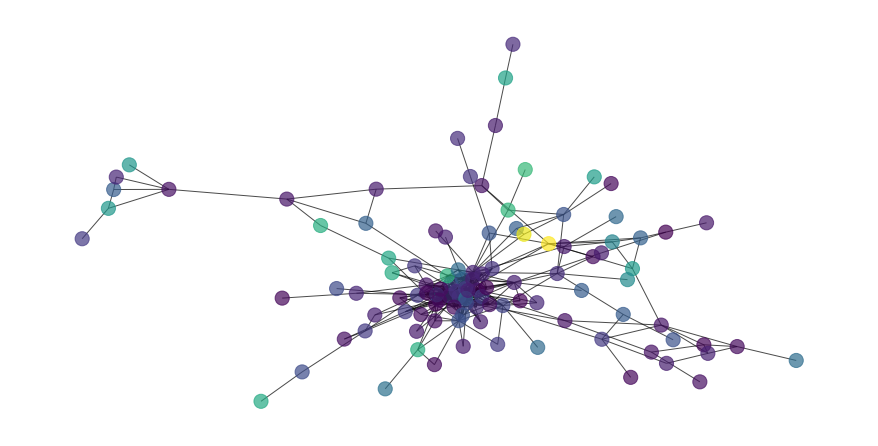

In [26]:
positions = nx.spring_layout(G1, seed = 18)
nx.draw(G1, node_color = expression_vals, node_size = 200, alpha = 0.7, pos = positions)
plt.savefig("expression")

### What could be done next?

<div class="alert alert-block alert-info"> <b></b> Based on the plot it seems that the community structure disappears in the random network. How do we make this more quantitative? We can quantify <b>modularity</b> of the community partition in the original network vs. randomized network. (And repeat the randomization many times to get a representative number).
We can also compare it to external functions - e.g. do proteins in the same community likely also belong to the same funcional group/pathway?
</div>

